In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Extract list of spliceosomal proteins

# Read the file
with open('spliceosome.txt', 'r') as f:
    content = f.read()

# Extract all symbols
symbols = re.findall(r'"symbol":"([^"]+)"', content)

# Get unique symbols and sort alphabetically
unique_symbols = sorted(set(symbols))

# Create comma-separated list
result = ', '.join(unique_symbols)
print(result)

ACIN1, ALYREF, AQR, BCAS2, BUD13, BUD31, C19ORF43, CACTIN, CD2BP2, CDC40, CDC5L, CDK12, CFAP20, CIRBP, CPSF6, CRNKL1, CTNNBL1, CWC15, CWC22, DDX17, DDX23, DDX39B, DDX3X, DDX41, DDX46, DDX5, DGCR14, DHX15, DHX16, DHX38, DHX8, DHX9, DNAJC8, EFTUD2, EIF4A3, HTATSF1, IGF2BP3, IK, ISY1, KIAA1429, LSM2, LSM3, LSM4, LSM6, LSM7, LUC7L3, MAGOH, MFAP1, MOV10, NCBP1, NCBP2, NHP2L1, NUDT21, PABPC1, PAXBP1, PLRG1, PPIE, PPIH, PPIL1, PPIL2, PPIL3, PPM1G, PPWD1, PRPF18, PRPF19, PRPF3, PRPF31, PRPF4, PRPF40A, PRPF4B, PRPF6, PRPF8, PUF60, RBM15, RBM17, RBM22, RBM25, RBM39, RBM8A, RNPS1, SART1, SF1, SF3A1, SF3A2, SF3A3, SF3B1, SF3B2, SF3B3, SF3B4, SF3B6, SKIV2L2, SLU7, SMNDC1, SMU1, SNRNP200, SNRNP27, SNRNP40, SNRNP70, SNRPA, SNRPA1, SNRPB, SNRPB2, SNRPC, SNRPD1, SNRPD2, SNRPD3, SNRPE, SNRPF, SNRPG, SNW1, SPEN, SRRM1, SRRM2, SRRT, SRSF1, SRSF11, SRSF2, SRSF3, SRSF4, SRSF5, SRSF6, SRSF7, SRSF9, SYF2, TCERG1, TFIP11, THOC1, THOC2, THOC3, THOC5, THOC6, THOC7, TRA2B, TXNL4A, U2AF1, U2AF2, U2SURP, USP39, WBP

In [4]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [5]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [6]:
# Set significance threshold

# Create sig_df with significant events
sig_df = table[
    (table['dPSI'].abs() >= 0.1) & 
    (table['rMATS FDR'] <= 0.05)
].copy()

In [7]:
# Extract each unique protein

unique_proteins = table['RBP_KD_Target'].unique()
print(', '.join(map(str, unique_proteins)))


AKAP1, AQR, BCCIP, BCLAF1, BUD13, CSTF2T, CSTF2, DDX3X, DDX52, DDX55, DDX59, DDX6, DKC1, EFTUD2, EIF3D, FAM120A, FASTKD2, FKBP4, FTO, FUBP3, FUS, G3BP1, GRSF1, GRWD1, GTF2F1, HLTF, HNRNPA1, HNRNPC, HNRNPK, HNRNPL, HNRNPM, HNRNPUL1, HNRNPU, IGF2BP3, ILF3, KHSRP, LARP4, LARP7, LIN28B, LSM11, MATR3, NCBP2, NIP7, NKRF, NOL12, NSUN2, PCBP1, PCBP2, PPIG, PRPF4, PRPF8, PTBP1, QKI, RBFOX2, RBM15, RBM22, SF3A3, SF3B4, SFPQ, SLTM, SMNDC1, SND1, SRSF1, SRSF9, SSB, SUB1, SUGP2, SUPV3L1, TAF15, TARDBP, TIA1, TIAL1, TRA2A, TROVE2, U2AF1, U2AF2, UCHL5, UPF1, UTP18, XPO5, XRCC6, XRN2, YBX3, AARS, AATF, ABCF1, AGGF1, AKAP8L, APOBEC3C, CPEB4, CPSF6, DDX1, DDX24, DDX47, DDX51, DHX30, DROSHA, EEF2, EIF3G, EIF4G2, EWSR1, FMR1, FXR1, GEMIN5, GPKOW, IGF2BP2, KHDRBS1, MBNL1, METAP2, MTPAP, NONO, PABPC4, PHF6, PPIL4, PUM1, PUM2, RPS10, SAFB2, SERBP1, SLBP, TBRG4, UTP3, WDR3, WDR43, WRN, ZC3H8, ZRANB2


In [8]:
# Spliceosomal

# Filter proteins that match symbols
matched_proteins = [protein for protein in unique_proteins if protein in unique_symbols]

# Print the results
print(matched_proteins)

['AQR', 'BUD13', 'DDX3X', 'EFTUD2', 'IGF2BP3', 'NCBP2', 'PRPF4', 'PRPF8', 'RBM15', 'RBM22', 'SF3A3', 'SF3B4', 'SMNDC1', 'SRSF1', 'SRSF9', 'U2AF1', 'U2AF2', 'CPSF6']


In [9]:
# Non-spliceosomal


# Get proteins NOT in symbols
unmatched_proteins = [protein for protein in unique_proteins if protein not in unique_symbols]

print(unmatched_proteins)

['AKAP1', 'BCCIP', 'BCLAF1', 'CSTF2T', 'CSTF2', 'DDX52', 'DDX55', 'DDX59', 'DDX6', 'DKC1', 'EIF3D', 'FAM120A', 'FASTKD2', 'FKBP4', 'FTO', 'FUBP3', 'FUS', 'G3BP1', 'GRSF1', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPUL1', 'HNRNPU', 'ILF3', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'NIP7', 'NKRF', 'NOL12', 'NSUN2', 'PCBP1', 'PCBP2', 'PPIG', 'PTBP1', 'QKI', 'RBFOX2', 'SFPQ', 'SLTM', 'SND1', 'SSB', 'SUB1', 'SUGP2', 'SUPV3L1', 'TAF15', 'TARDBP', 'TIA1', 'TIAL1', 'TRA2A', 'TROVE2', 'UCHL5', 'UPF1', 'UTP18', 'XPO5', 'XRCC6', 'XRN2', 'YBX3', 'AARS', 'AATF', 'ABCF1', 'AGGF1', 'AKAP8L', 'APOBEC3C', 'CPEB4', 'DDX1', 'DDX24', 'DDX47', 'DDX51', 'DHX30', 'DROSHA', 'EEF2', 'EIF3G', 'EIF4G2', 'EWSR1', 'FMR1', 'FXR1', 'GEMIN5', 'GPKOW', 'IGF2BP2', 'KHDRBS1', 'MBNL1', 'METAP2', 'MTPAP', 'NONO', 'PABPC4', 'PHF6', 'PPIL4', 'PUM1', 'PUM2', 'RPS10', 'SAFB2', 'SERBP1', 'SLBP', 'TBRG4', 'UTP3', 'WDR3', 'WDR43', 'WRN', 'ZC3H8', 'ZRANB2']


In [13]:
def make_layered_scatterplot(protein_list, cell_line):
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Define colors for each protein
    colors = [
        'red',
        'blue',
        'green',
        'yellow',
        'purple',
        'orange',
        'pink',
        'brown',
        'gray',
        'black',
        'cyan',
        'magenta',
        'lime',
        'navy',
        'teal',
        'coral',
        'gold',
        'darkred'
    ]
    
    # Plot each protein with a different color
    for i, protein in enumerate(protein_list):
        # Filter for all rows where Feature contains the protein name
        plot_df = table[
            (table["Feature"].str.contains(protein, case=False, na=False)) & 
            (table["Cell Line"] == cell_line)
        ]
        
        # Only plot if there's data for this protein
        if not plot_df.empty:
            ax.scatter(plot_df["CTRL - KD Local SHAP"], plot_df["dPSI"], 
                       alpha=0.2, s=15, color=colors[i], label=protein)
    
    # Add quadrant lines at x=0 and y=0 (OUTSIDE the loop)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants (OUTSIDE the loop)
    # Filter for all features that contain any of the proteins
    mask = table["Feature"].str.contains('|'.join(protein_list), case=False, na=False)
    all_data = table[mask & (table["Cell Line"] == cell_line)]
    
    all_x = all_data["CTRL - KD Local SHAP"]
    all_y = all_data["dPSI"]
    
    x_max = max(abs(all_x.min()), abs(all_x.max()))
    y_max = max(abs(all_y.min()), abs(all_y.max()))
    
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title(f"Candidate Features in {cell_line}", fontsize=18, pad=20)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add legend
    ax.legend(fontsize=12, loc='best', framealpha=0.9)
    
    # Add text box with number of points
    num_points = len(all_data)
    textstr = f'n = {num_points}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

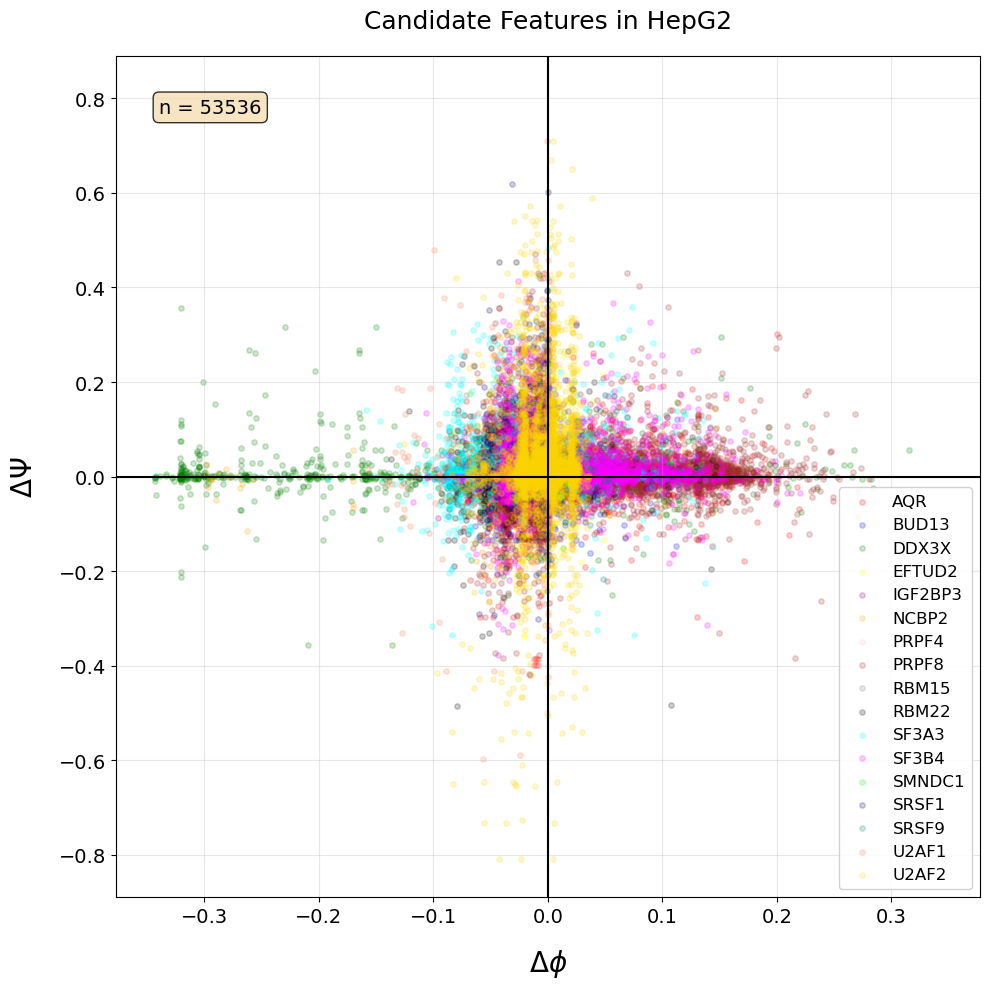

In [14]:
make_layered_scatterplot(matched_proteins, "HepG2")

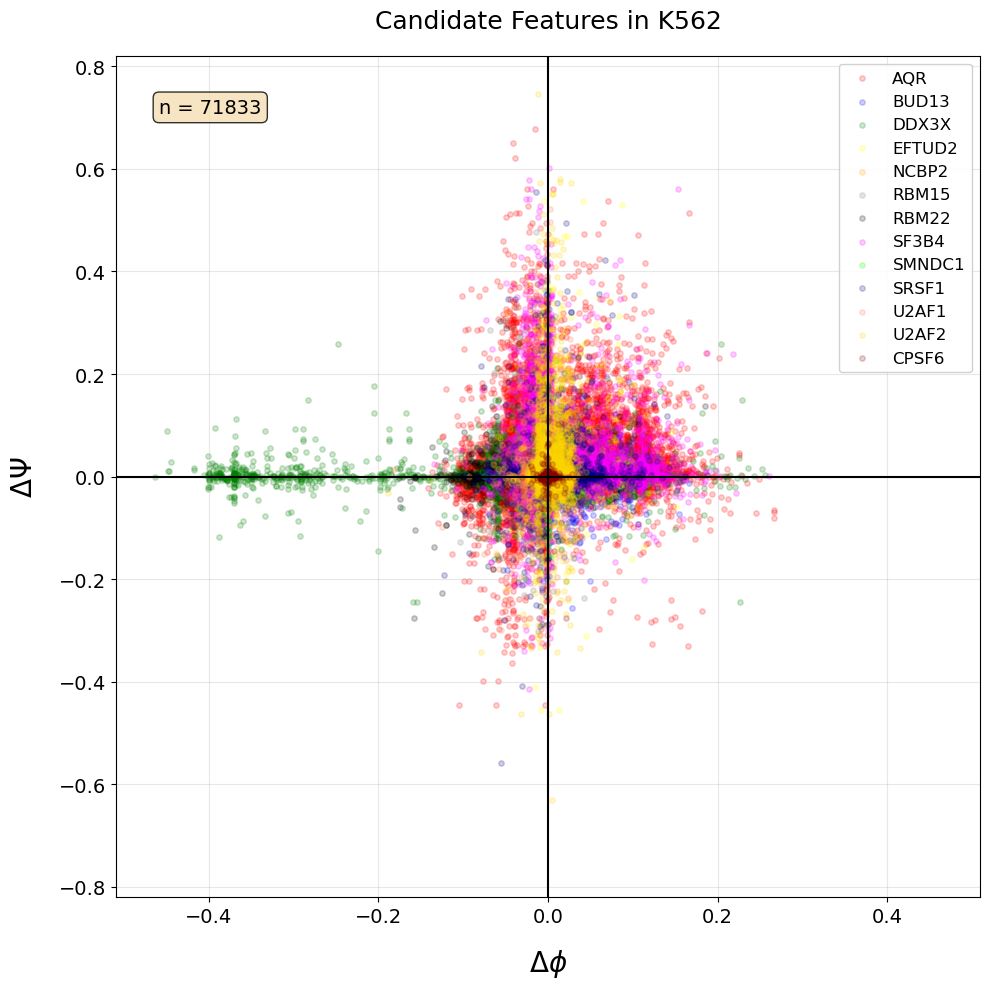

In [15]:
make_layered_scatterplot(matched_proteins, "K562")

In [19]:
def make_layered_scatterplot2(protein_list, cell_line):
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Filter for all features that contain any of the proteins
    mask = table["Feature"].str.contains('|'.join(protein_list), case=False, na=False)
    plot_df = table[mask & (table["Cell Line"] == cell_line)]
    
    # Plot all points with a single color
    ax.scatter(plot_df["CTRL - KD Local SHAP"], plot_df["dPSI"], 
               alpha=0.6, s=15, color='blue')
    
    # Add quadrant lines at x=0 and y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants
    all_x = plot_df["CTRL - KD Local SHAP"]
    all_y = plot_df["dPSI"]
    
    x_max = max(abs(all_x.min()), abs(all_x.max()))
    y_max = max(abs(all_y.min()), abs(all_y.max()))
    
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title(f"Candidate Features in {cell_line}", fontsize=18, pad=20)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add text box with number of points
    num_points = len(plot_df)
    textstr = f'n = {num_points}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()